#Zeyad_Sherif -- 202201220

In [1]:
import os
import math
import random
import time
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, metrics
from sklearn.decomposition import PCA
from google.colab import drive

In [2]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

IMAGE_SIZE = 64
BATCH_SIZE = 64
LATENT_DIM = 16
EPOCHS = 10
NOISE_FACTOR = 0.2

TensorFlow Version: 2.19.0
Num GPUs Available: 0


In [7]:
drive.mount('/content/drive')
!unzip -q "/content/drive/MyDrive/archive.zip" -d "/content/Medical_MNIST"

DATA_ROOT = "/content/Medical_MNIST"


EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

region_data = {}

for p in Path(DATA_ROOT).rglob("*"):
    if p.suffix.lower() in EXTS:
        region_name = p.parent.name
        if region_name not in region_data:
            region_data[region_name] = []
        region_data[region_name].append(str(p))

print("\nImages per anatomical region:")
for region, paths in sorted(region_data.items()):
    print(f"- {region}: {len(paths)} images")

for region in region_data:
    random.shuffle(region_data[region])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Images per anatomical region:
- AbdomenCT: 10000 images
- BreastMRI: 8954 images
- CXR: 10000 images
- ChestCT: 10000 images
- Hand: 10000 images
- HeadCT: 10000 images


In [ ]:
def parse_image(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    return img

In [ ]:
def add_noise(image):
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=NOISE_FACTOR, dtype=tf.float32)
    noisy_image = tf.clip_by_value(image + noise, 0.0, 1.0)
    return noisy_image

In [3]:
def build_dataset(paths, mode='clean', is_training=False):
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()

    if is_training:
        ds = ds.shuffle(buffer_size=1000)

    if mode == 'denoise':
        ds = ds.map(lambda x: (add_noise(x), x), num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(lambda x: (x, x), num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [ ]:
class ConvAE(tf.keras.Model):
    def __init__(self, latent_dim=16, image_size=64):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = models.Sequential([
            layers.InputLayer(input_shape=(image_size, image_size, 3)),
            layers.Conv2D(32, 4, strides=2, padding='same', activation='relu'),
            layers.Conv2D(64, 4, strides=2, padding='same', activation='relu'),
            layers.Conv2D(128, 4, strides=2, padding='same', activation='relu'),
            layers.Flatten(),
            layers.Dense(latent_dim)
        ], name="ae_encoder")

        flat_shape = (image_size // 8) * (image_size // 8) * 128
        self.decoder = models.Sequential([
            layers.InputLayer(input_shape=(latent_dim,)),
            layers.Dense(flat_shape, activation='relu'),
            layers.Reshape((image_size // 8, image_size // 8, 128)),
            layers.Conv2DTranspose(64, 4, strides=2, padding='same', activation='relu'),
            layers.Conv2DTranspose(32, 4, strides=2, padding='same', activation='relu'),
            layers.Conv2DTranspose(3, 4, strides=2, padding='same', activation='sigmoid')
        ], name="ae_decoder")

    def call(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [ ]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [4]:
class ConvVAE(tf.keras.Model):
    def __init__(self, latent_dim=16, image_size=64, beta=1.0):
        super().__init__()
        self.latent_dim = latent_dim
        self.beta = beta

        self.encoder_conv = models.Sequential([
            layers.InputLayer(input_shape=(image_size, image_size, 3)),
            layers.Conv2D(32, 4, strides=2, padding='same', activation='relu'),
            layers.Conv2D(64, 4, strides=2, padding='same', activation='relu'),
            layers.Conv2D(128, 4, strides=2, padding='same', activation='relu'),
            layers.Flatten()
        ])

        self.fc_mu = layers.Dense(latent_dim, name="z_mean")
        self.fc_logvar = layers.Dense(latent_dim, name="z_log_var")
        self.sampling = Sampling()

        flat_shape = (image_size // 8) * (image_size // 8) * 128
        self.decoder = models.Sequential([
            layers.InputLayer(input_shape=(latent_dim,)),
            layers.Dense(flat_shape, activation='relu'),
            layers.Reshape((image_size // 8, image_size // 8, 128)),
            layers.Conv2DTranspose(64, 4, strides=2, padding='same', activation='relu'),
            layers.Conv2DTranspose(32, 4, strides=2, padding='same', activation='relu'),
            layers.Conv2DTranspose(3, 4, strides=2, padding='same', activation='sigmoid')
        ], name="vae_decoder")

        self.total_loss_tracker = metrics.Mean(name="loss")
        self.recon_loss_tracker = metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def encode(self, x):
        h = self.encoder_conv(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def call(self, x):
        mu, logvar = self.encode(x)
        z = self.sampling((mu, logvar))
        return self.decoder(z)

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            mu, logvar = self.encode(x)
            z = self.sampling((mu, logvar))
            x_hat = self.decoder(z)

            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.keras.losses.mse(x, x_hat), axis=(1, 2)))
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1))
            total_loss = recon_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, _ = data
        mu, logvar = self.encode(x)
        z = self.sampling((mu, logvar))
        x_hat = self.decoder(z)

        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.keras.losses.mse(x, x_hat), axis=(1, 2)))
        kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1))
        total_loss = recon_loss + self.beta * kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

In [ ]:
def plot_training_history(ae_hist, vae_hist, region_name):
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(ae_hist.history['loss'], label="Train")
    plt.plot(ae_hist.history['val_loss'], label="Val")
    plt.title(f"{region_name}: AE (Denoising) Loss")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(vae_hist.history['recon_loss'], label="Recon Train")
    plt.plot(vae_hist.history['val_recon_loss'], label="Recon Val")
    plt.title(f"{region_name}: VAE Recon Loss")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(vae_hist.history['kl_loss'], label="KL Train")
    plt.plot(vae_hist.history['val_kl_loss'], label="KL Val")
    plt.title(f"{region_name}: VAE KL Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_reconstruction_and_denoising(ae, vae, clean_loader, noisy_loader, n=6):
    for (clean_x, _), (noisy_x, _) in zip(clean_loader.take(1), noisy_loader.take(1)):
        clean_batch = clean_x[:n]
        noisy_batch = noisy_x[:n]
        break

    ae_denoised = ae.predict(noisy_batch, verbose=0)
    vae_recon = vae.predict(clean_batch, verbose=0)

    fig, axes = plt.subplots(4, n, figsize=(2*n, 8))
    for i in range(n):

        axes[0, i].imshow(clean_batch[i].numpy())
        axes[0, i].set_title("Original")
        axes[0, i].axis("off")

        axes[1, i].imshow(noisy_batch[i].numpy())
        axes[1, i].set_title("Noisy Input")
        axes[1, i].axis("off")

        axes[2, i].imshow(ae_denoised[i])
        axes[2, i].set_title("DAE Cleaned")
        axes[2, i].axis("off")

        axes[3, i].imshow(vae_recon[i])
        axes[3, i].set_title("VAE Recon (Clean)")
        axes[3, i].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_latent_space(vae, loader, title="VAE Latent Space (PCA)"):
    latents = []
    for x_batch, _ in loader:
        mu, _ = vae.encode(x_batch)
        latents.append(mu.numpy())
    z = np.concatenate(latents, axis=0)

    pca = PCA(n_components=2)
    z2 = pca.fit_transform(z)

    plt.figure(figsize=(6, 5))
    plt.scatter(z2[:, 0], z2[:, 1], s=10, alpha=0.5, c='purple')
    plt.title(title)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.tight_layout()
    plt.show()

In [5]:
def generate_samples(vae, n=8):
    z = tf.random.normal(shape=(n, vae.latent_dim))
    generated = vae.decoder(z).numpy()

    plt.figure(figsize=(12, 3))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(generated[i])
        plt.axis("off")
    plt.suptitle("Generated Samples from VAE Prior", fontsize=14)
    plt.tight_layout()
    plt.show()

In [6]:
EPOCHS = 100
strategy = tf.distribute.MirroredStrategy()

for region, paths in sorted(region_data.items()):
    print(f" STARTING EXPERIMENT FOR REGION: {region.upper()}")

    n_total = len(paths)
    n_train = int(0.7 * n_total)
    n_val = int(0.15 * n_total)

    train_paths = paths[:n_train]
    val_paths = paths[n_train:n_train+n_val]
    test_paths = paths[n_train+n_val:]


    train_dae_ds = build_dataset(train_paths, mode='denoise', is_training=True)
    val_dae_ds = build_dataset(val_paths, mode='denoise', is_training=False)

    train_vae_ds = build_dataset(train_paths, mode='clean', is_training=True)
    val_vae_ds = build_dataset(val_paths, mode='clean', is_training=False)

    test_clean_ds = build_dataset(test_paths, mode='clean', is_training=False)
    test_noisy_ds = build_dataset(test_paths, mode='denoise', is_training=False)

    with strategy.scope():
        ae_model = ConvAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE)
        ae_model.compile(optimizer='adam', loss='mse')

        vae_model = ConvVAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE, beta=1.0)
        vae_model.compile(optimizer='adam')

    print(f"\n--- Training Denoising AE for {region} ---")
    ae_history = ae_model.fit(
        train_dae_ds,
        validation_data=val_dae_ds,
        epochs=EPOCHS,
        verbose=1
    )

    print(f"\n--- Training VAE for {region} ---")
    vae_history = vae_model.fit(
        train_vae_ds,
        validation_data=val_vae_ds,
        epochs=EPOCHS,
        verbose=1
    )

    print(f"\n--- Generating Analytics for {region} ---")

    plot_training_history(ae_history, vae_history, region)

    evaluate_reconstruction_and_denoising(ae_model, vae_model, test_clean_ds, test_noisy_ds, n=6)

    plot_latent_space(vae_model, test_clean_ds, title=f"{region}: VAE Latent Space")

    generate_samples(vae_model, n=6)

    print(f" FINISHED EXPERIMENT FOR REGION: {region.upper()}\n\n")

In [7]:
EPOCHS = 100

strategy = tf.distribute.MirroredStrategy()

 STARTING EXPERIMENT FOR REGION: ABDOMENCT


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



--- Training Denoising AE for AbdomenCT ---
Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - loss: 0.0092 - val_loss: 0.0069
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0055 - val_loss: 0.0050
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0044 - val_loss: 0.0041
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0038 - val_loss: 0.0036
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0034 - val_loss: 0.0033
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 10/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 11/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0024 - va

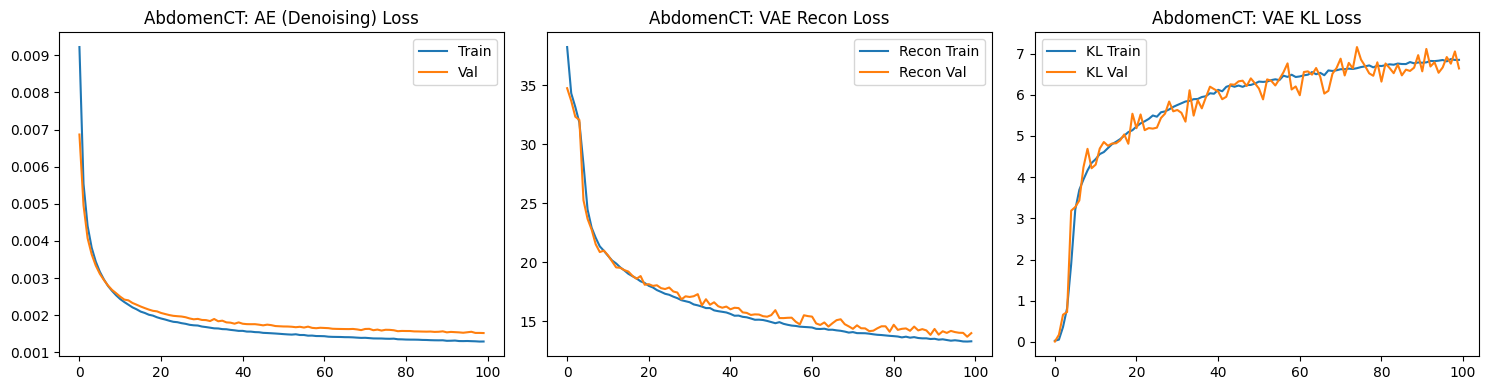

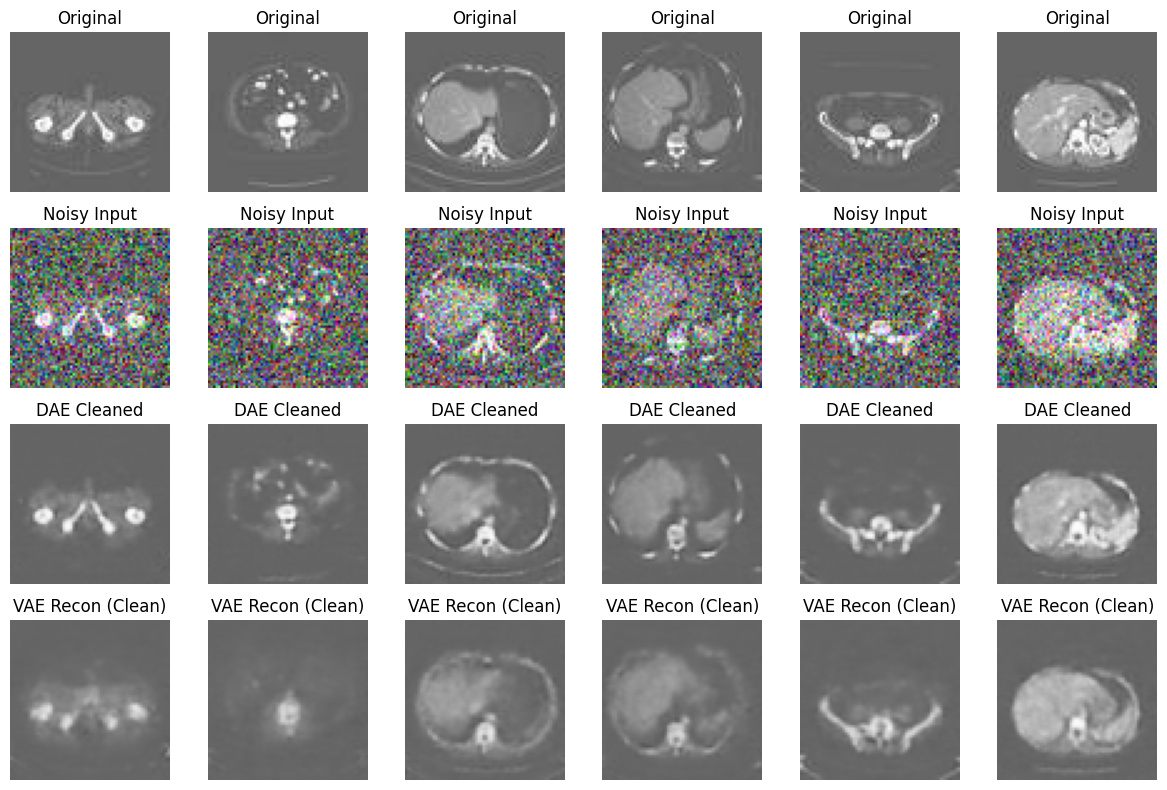

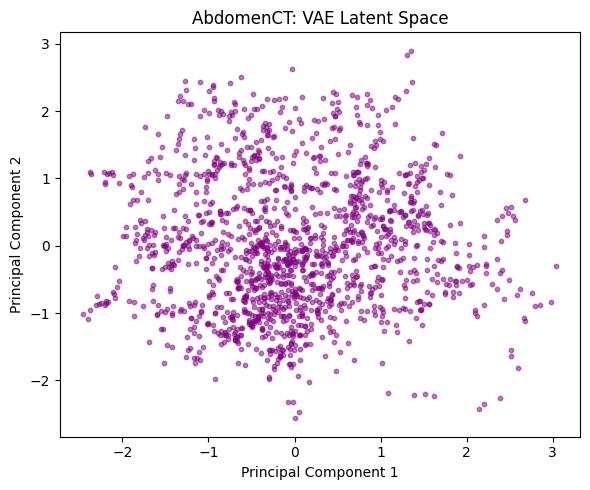

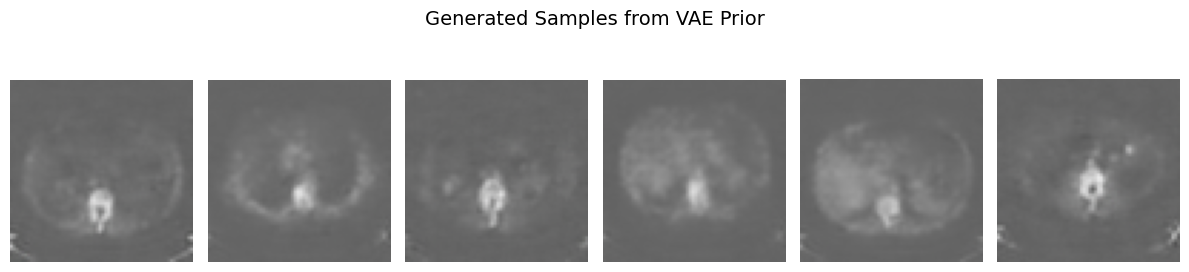

 FINISHED EXPERIMENT FOR REGION: ABDOMENCT




In [27]:
tf.keras.backend.clear_session()
region = "AbdomenCT"
paths = region_data[region]

print(f" STARTING EXPERIMENT FOR REGION: {region.upper()}")

n_total = len(paths)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

train_paths = paths[:n_train]
val_paths = paths[n_train:n_train+n_val]
test_paths = paths[n_train+n_val:]

train_dae_ds = build_dataset(train_paths, mode='denoise', is_training=True)
val_dae_ds = build_dataset(val_paths, mode='denoise', is_training=False)
train_vae_ds = build_dataset(train_paths, mode='clean', is_training=True)
val_vae_ds = build_dataset(val_paths, mode='clean', is_training=False)
test_clean_ds = build_dataset(test_paths, mode='clean', is_training=False)
test_noisy_ds = build_dataset(test_paths, mode='denoise', is_training=False)

with strategy.scope():
    ae_model = ConvAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE)
    ae_model.compile(optimizer='adam', loss='mse')
    vae_model = ConvVAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE, beta=1.0)
    vae_model.compile(optimizer='adam')

print(f"\n--- Training Denoising AE for {region} ---")
ae_history = ae_model.fit(train_dae_ds, validation_data=val_dae_ds, epochs=EPOCHS, verbose=1)

print(f"\n--- Training VAE for {region} ---")
vae_history = vae_model.fit(train_vae_ds, validation_data=val_vae_ds, epochs=EPOCHS, verbose=1)

print(f"\n--- Generating Analytics for {region} ---")
plot_training_history(ae_history, vae_history, region)
evaluate_reconstruction_and_denoising(ae_model, vae_model, test_clean_ds, test_noisy_ds, n=6)
plot_latent_space(vae_model, test_clean_ds, title=f"{region}: VAE Latent Space")
generate_samples(vae_model, n=6)
print(f" FINISHED EXPERIMENT FOR REGION: {region.upper()}\n\n")

 STARTING EXPERIMENT FOR REGION: BREASTMRI


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



--- Training Denoising AE for BreastMRI ---
Epoch 1/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 26s 230ms/step - loss: 0.0770 - val_loss: 0.0577
Epoch 2/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0588 - val_loss: 0.0577
Epoch 3/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0588 - val_loss: 0.0577
Epoch 4/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0588 - val_loss: 0.0577
Epoch 5/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0588 - val_loss: 0.0577
Epoch 6/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.0588 - val_loss: 0.0577
Epoch 7/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0588 - val_loss: 0.0577
Epoch 8/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0588 - val_loss: 0.0577
Epoch 9/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0588 - val_loss: 0.0577
Epoch 10/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0588 - val_loss: 0.0577
Epoch 11/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0588 - val_loss: 0.0577
Epoch

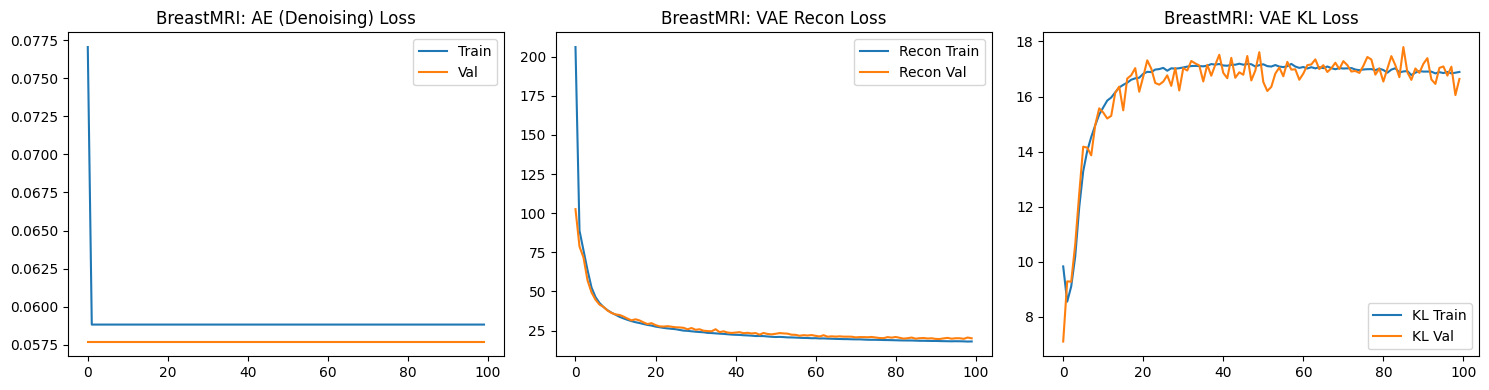

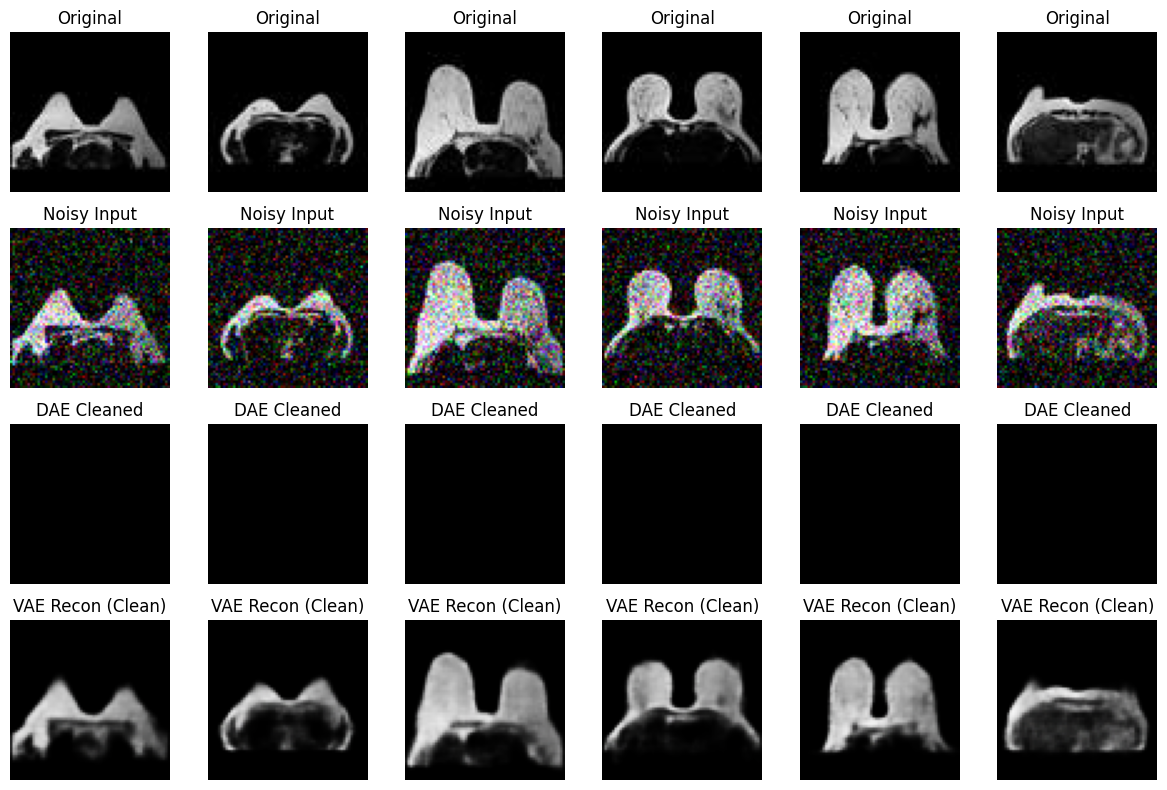

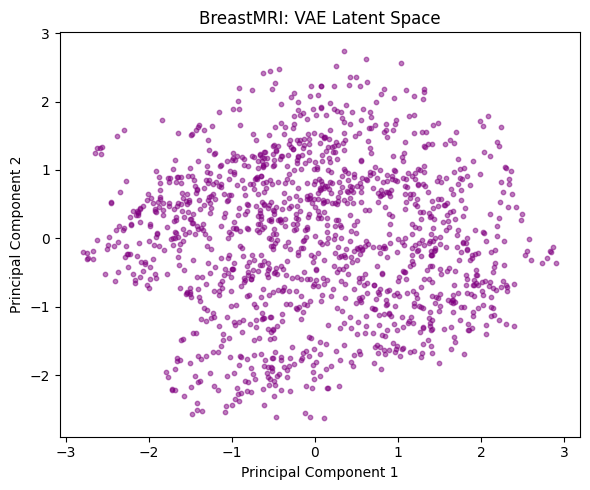

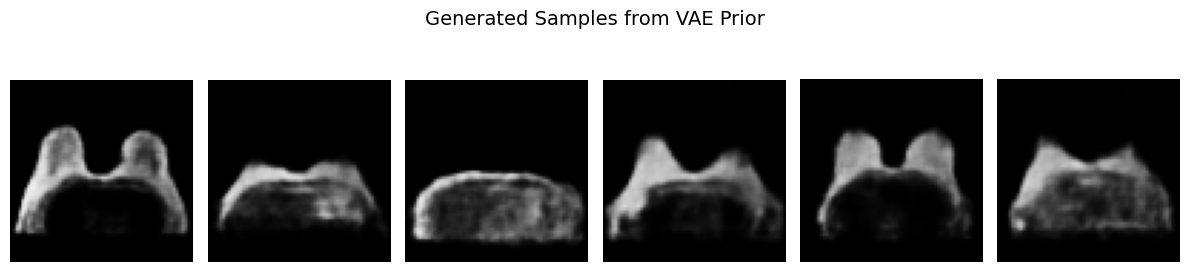

 FINISHED EXPERIMENT FOR REGION: BREASTMRI




In [8]:
tf.keras.backend.clear_session()
region = "BreastMRI"
paths = region_data[region]

print(f" STARTING EXPERIMENT FOR REGION: {region.upper()}")

n_total = len(paths)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

train_paths = paths[:n_train]
val_paths = paths[n_train:n_train+n_val]
test_paths = paths[n_train+n_val:]

train_dae_ds = build_dataset(train_paths, mode='denoise', is_training=True)
val_dae_ds = build_dataset(val_paths, mode='denoise', is_training=False)
train_vae_ds = build_dataset(train_paths, mode='clean', is_training=True)
val_vae_ds = build_dataset(val_paths, mode='clean', is_training=False)
test_clean_ds = build_dataset(test_paths, mode='clean', is_training=False)
test_noisy_ds = build_dataset(test_paths, mode='denoise', is_training=False)

with strategy.scope():
    ae_model = ConvAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE)
    ae_model.compile(optimizer='adam', loss='mse')
    vae_model = ConvVAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE, beta=1.0)
    vae_model.compile(optimizer='adam')

print(f"\n--- Training Denoising AE for {region} ---")
ae_history = ae_model.fit(train_dae_ds, validation_data=val_dae_ds, epochs=EPOCHS, verbose=1)

print(f"\n--- Training VAE for {region} ---")
vae_history = vae_model.fit(train_vae_ds, validation_data=val_vae_ds, epochs=EPOCHS, verbose=1)

print(f"\n--- Generating Analytics for {region} ---")
plot_training_history(ae_history, vae_history, region)
evaluate_reconstruction_and_denoising(ae_model, vae_model, test_clean_ds, test_noisy_ds, n=6)
plot_latent_space(vae_model, test_clean_ds, title=f"{region}: VAE Latent Space")
generate_samples(vae_model, n=6)
print(f" FINISHED EXPERIMENT FOR REGION: {region.upper()}\n\n")

 STARTING EXPERIMENT FOR REGION: CXR


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



--- Training Denoising AE for CXR ---
Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 33s 284ms/step - loss: 0.0469 - val_loss: 0.0203
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0166 - val_loss: 0.0139
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0126 - val_loss: 0.0112
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0106 - val_loss: 0.0098
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0096 - val_loss: 0.0094
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0091 - val_loss: 0.0091
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0086 - val_loss: 0.0086
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0082 - val_loss: 0.0083
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0079 - val_loss: 0.0081
Epoch 10/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0077 - val_loss: 0.0081
Epoch 11/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0076 - val_lo

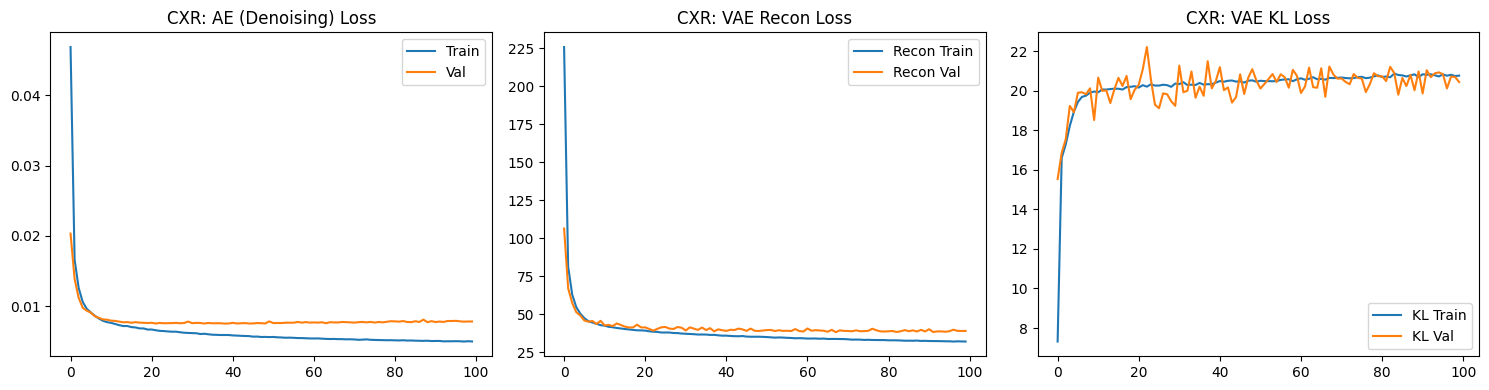

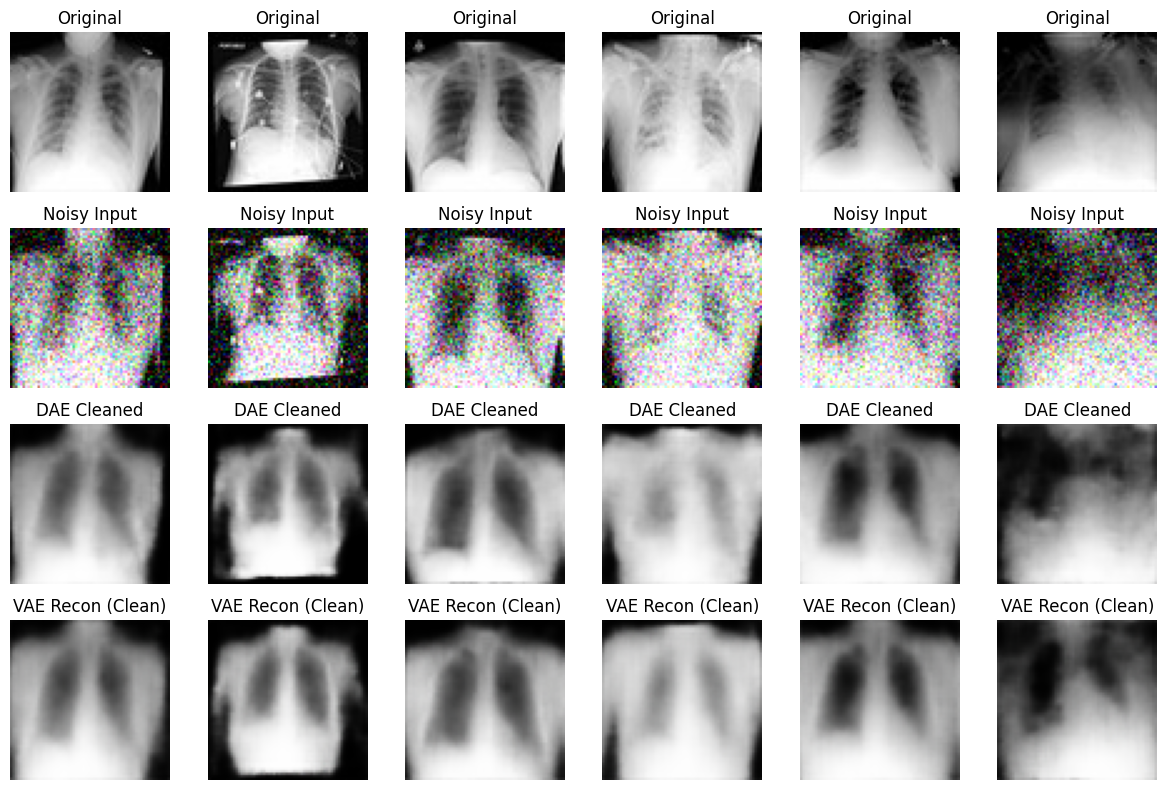

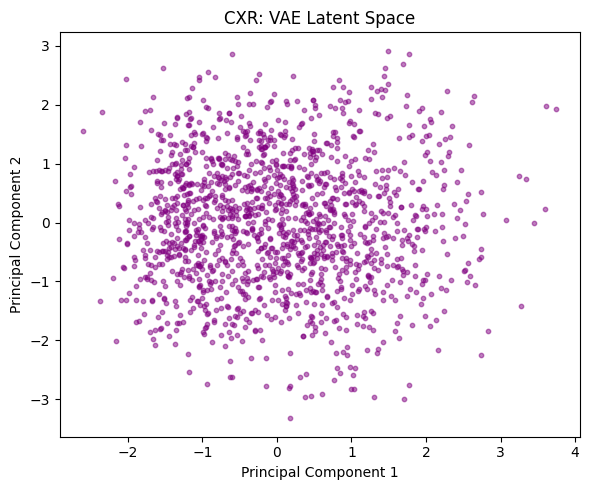

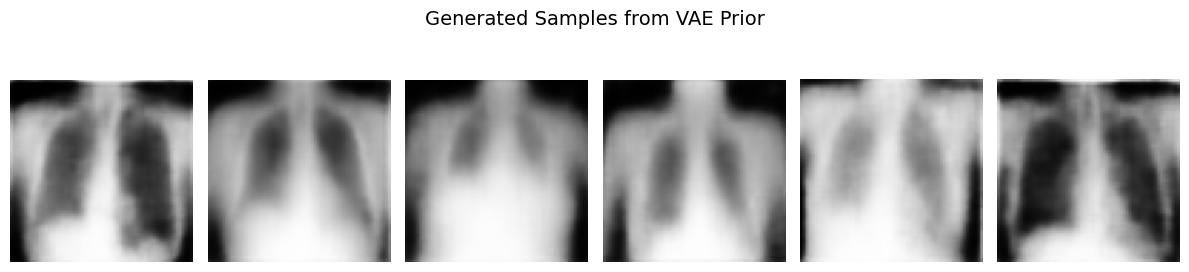

 FINISHED EXPERIMENT FOR REGION: CXR




In [9]:
tf.keras.backend.clear_session()
region = "CXR"
paths = region_data[region]

print(f" STARTING EXPERIMENT FOR REGION: {region.upper()}")

n_total = len(paths)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

train_paths = paths[:n_train]
val_paths = paths[n_train:n_train+n_val]
test_paths = paths[n_train+n_val:]

train_dae_ds = build_dataset(train_paths, mode='denoise', is_training=True)
val_dae_ds = build_dataset(val_paths, mode='denoise', is_training=False)
train_vae_ds = build_dataset(train_paths, mode='clean', is_training=True)
val_vae_ds = build_dataset(val_paths, mode='clean', is_training=False)
test_clean_ds = build_dataset(test_paths, mode='clean', is_training=False)
test_noisy_ds = build_dataset(test_paths, mode='denoise', is_training=False)

with strategy.scope():
    ae_model = ConvAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE)
    ae_model.compile(optimizer='adam', loss='mse')
    vae_model = ConvVAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE, beta=1.0)
    vae_model.compile(optimizer='adam')

print(f"\n--- Training Denoising AE for {region} ---")
ae_history = ae_model.fit(train_dae_ds, validation_data=val_dae_ds, epochs=EPOCHS, verbose=1)

print(f"\n--- Training VAE for {region} ---")
vae_history = vae_model.fit(train_vae_ds, validation_data=val_vae_ds, epochs=EPOCHS, verbose=1)

print(f"\n--- Generating Analytics for {region} ---")
plot_training_history(ae_history, vae_history, region)
evaluate_reconstruction_and_denoising(ae_model, vae_model, test_clean_ds, test_noisy_ds, n=6)
plot_latent_space(vae_model, test_clean_ds, title=f"{region}: VAE Latent Space")
generate_samples(vae_model, n=6)
print(f" FINISHED EXPERIMENT FOR REGION: {region.upper()}\n\n")

 STARTING EXPERIMENT FOR REGION: CHESTCT


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



--- Training Denoising AE for ChestCT ---
Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 35s 297ms/step - loss: 0.0034 - val_loss: 0.0033
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0029 - val_loss: 0.0029
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 10/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 11/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0025 - va

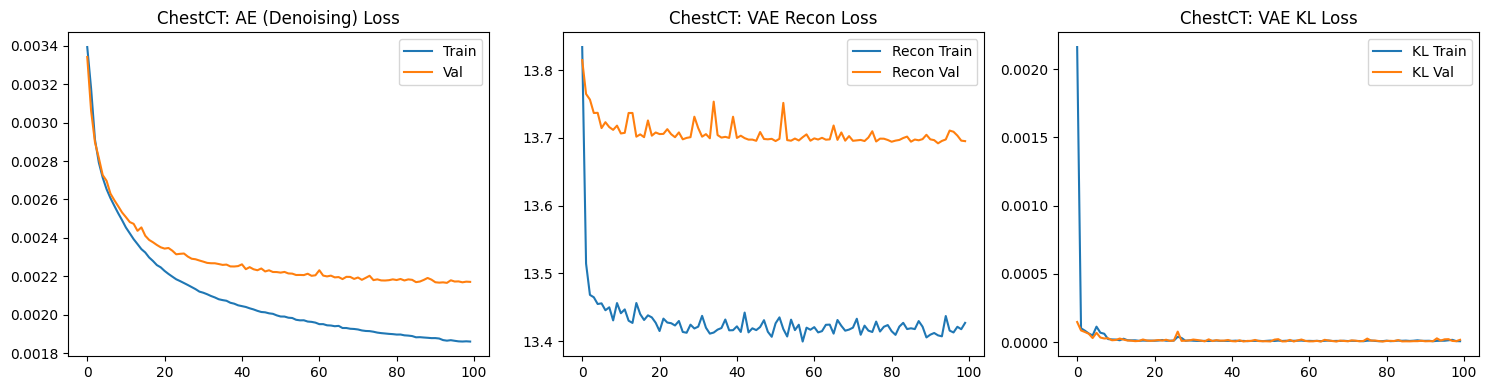

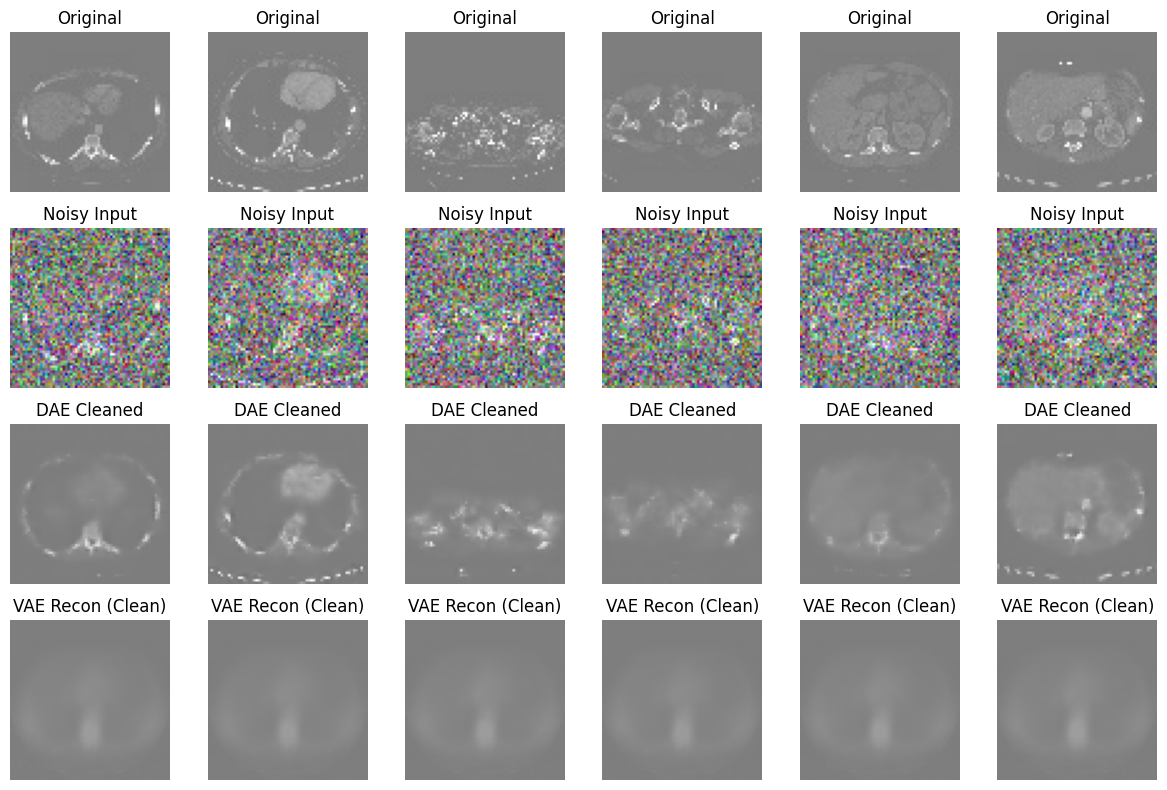

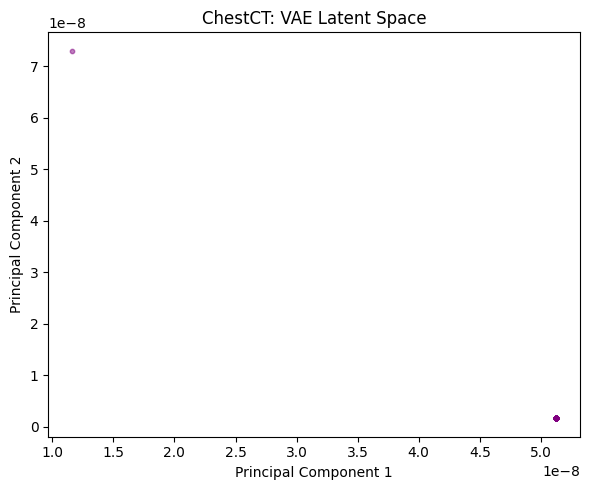

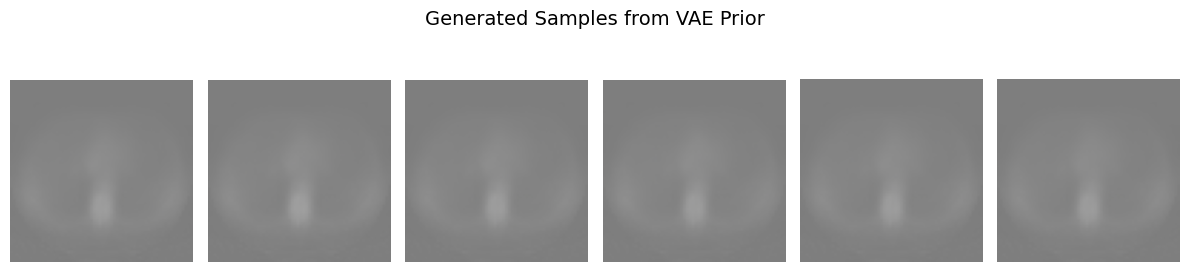

 FINISHED EXPERIMENT FOR REGION: CHESTCT




In [10]:
tf.keras.backend.clear_session()
region = "ChestCT"
paths = region_data[region]

print(f" STARTING EXPERIMENT FOR REGION: {region.upper()}")

n_total = len(paths)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

train_paths = paths[:n_train]
val_paths = paths[n_train:n_train+n_val]
test_paths = paths[n_train+n_val:]

train_dae_ds = build_dataset(train_paths, mode='denoise', is_training=True)
val_dae_ds = build_dataset(val_paths, mode='denoise', is_training=False)
train_vae_ds = build_dataset(train_paths, mode='clean', is_training=True)
val_vae_ds = build_dataset(val_paths, mode='clean', is_training=False)
test_clean_ds = build_dataset(test_paths, mode='clean', is_training=False)
test_noisy_ds = build_dataset(test_paths, mode='denoise', is_training=False)

with strategy.scope():
    ae_model = ConvAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE)
    ae_model.compile(optimizer='adam', loss='mse')
    vae_model = ConvVAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE, beta=1.0)
    vae_model.compile(optimizer='adam')

print(f"\n--- Training Denoising AE for {region} ---")
ae_history = ae_model.fit(train_dae_ds, validation_data=val_dae_ds, epochs=EPOCHS, verbose=1)

print(f"\n--- Training VAE for {region} ---")
vae_history = vae_model.fit(train_vae_ds, validation_data=val_vae_ds, epochs=EPOCHS, verbose=1)

print(f"\n--- Generating Analytics for {region} ---")
plot_training_history(ae_history, vae_history, region)
evaluate_reconstruction_and_denoising(ae_model, vae_model, test_clean_ds, test_noisy_ds, n=6)
plot_latent_space(vae_model, test_clean_ds, title=f"{region}: VAE Latent Space")
generate_samples(vae_model, n=6)
print(f" FINISHED EXPERIMENT FOR REGION: {region.upper()}\n\n")

 STARTING EXPERIMENT FOR REGION: HAND


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



--- Training Denoising AE for Hand ---
Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 33s 291ms/step - loss: 0.0604 - val_loss: 0.0294
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0231 - val_loss: 0.0192
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0162 - val_loss: 0.0151
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0130 - val_loss: 0.0122
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0109 - val_loss: 0.0112
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0097 - val_loss: 0.0100
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0090 - val_loss: 0.0095
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0085 - val_loss: 0.0092
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0082 - val_loss: 0.0088
Epoch 10/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0079 - val_loss: 0.0089
Epoch 11/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0077 - val_l

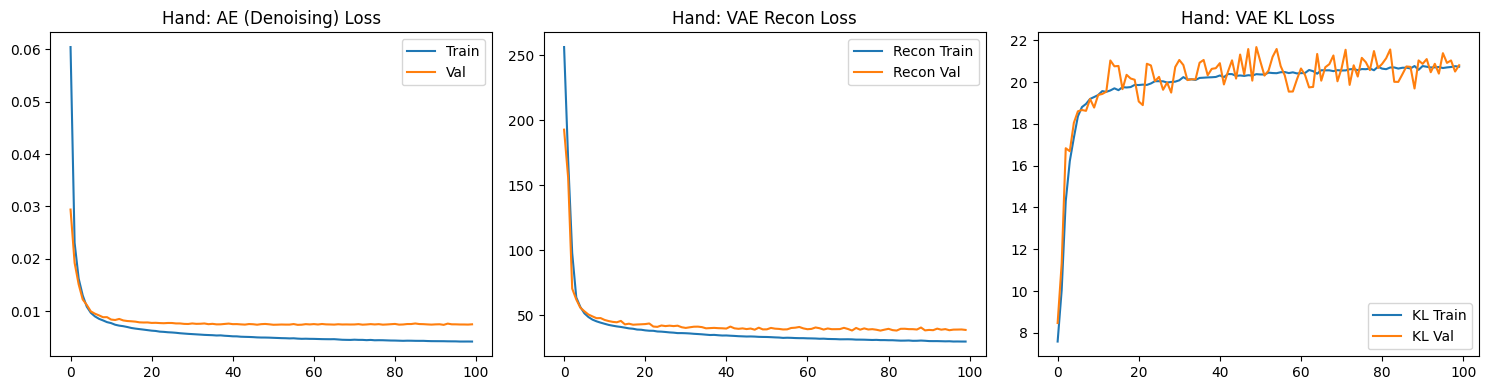

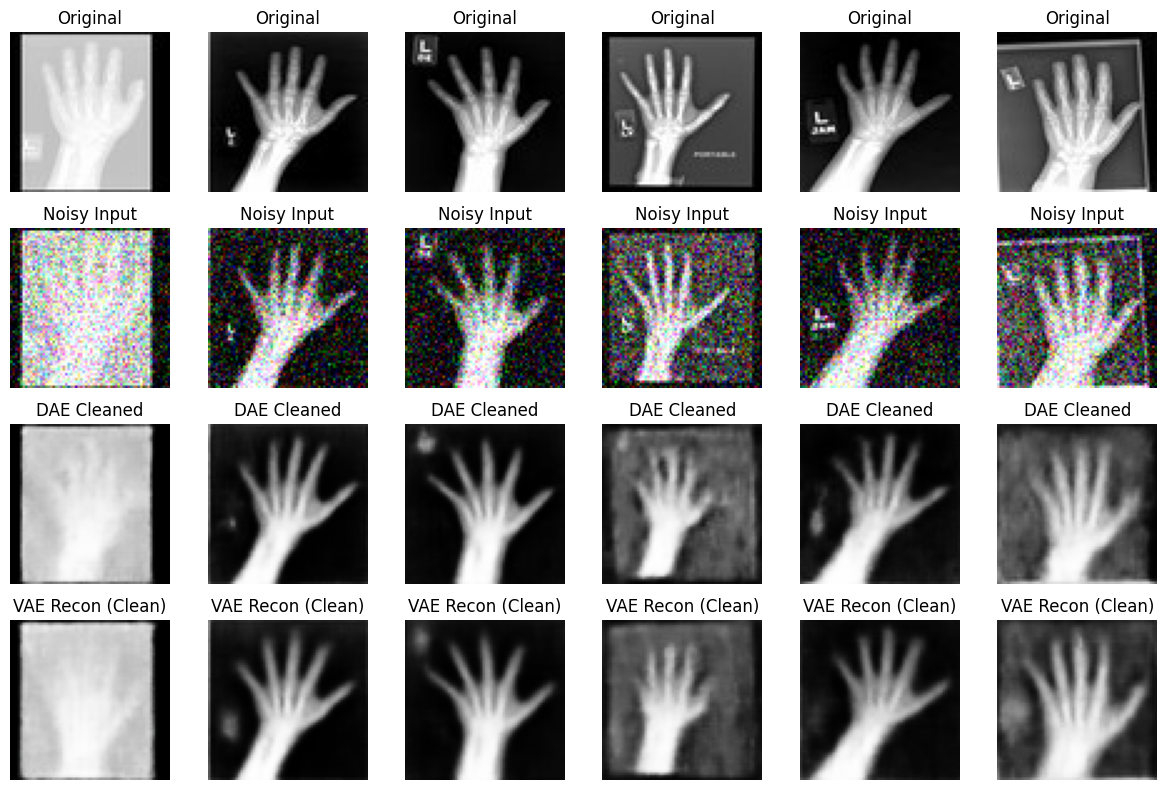

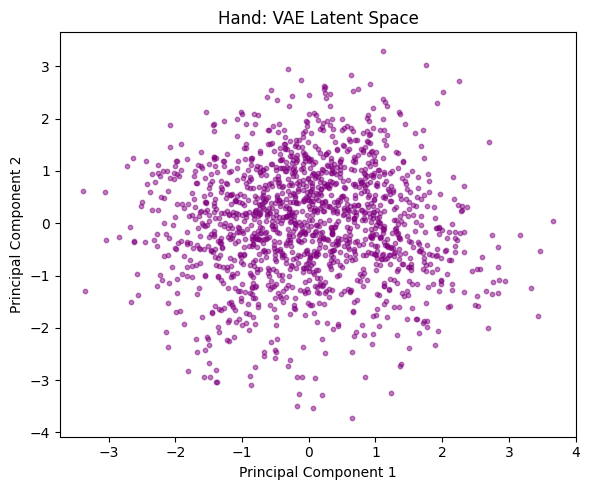

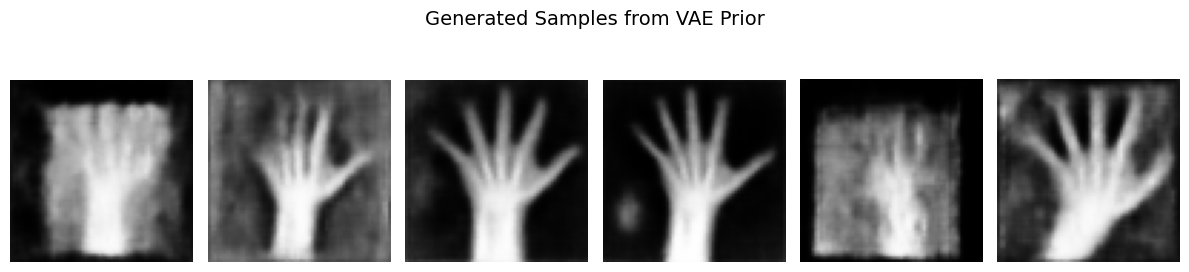

 FINISHED EXPERIMENT FOR REGION: HAND




In [11]:
tf.keras.backend.clear_session()
region = "Hand"
paths = region_data[region]

print(f" STARTING EXPERIMENT FOR REGION: {region.upper()}")

n_total = len(paths)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

train_paths = paths[:n_train]
val_paths = paths[n_train:n_train+n_val]
test_paths = paths[n_train+n_val:]

train_dae_ds = build_dataset(train_paths, mode='denoise', is_training=True)
val_dae_ds = build_dataset(val_paths, mode='denoise', is_training=False)
train_vae_ds = build_dataset(train_paths, mode='clean', is_training=True)
val_vae_ds = build_dataset(val_paths, mode='clean', is_training=False)
test_clean_ds = build_dataset(test_paths, mode='clean', is_training=False)
test_noisy_ds = build_dataset(test_paths, mode='denoise', is_training=False)

with strategy.scope():
    ae_model = ConvAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE)
    ae_model.compile(optimizer='adam', loss='mse')
    vae_model = ConvVAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE, beta=1.0)
    vae_model.compile(optimizer='adam')

print(f"\n--- Training Denoising AE for {region} ---")
ae_history = ae_model.fit(train_dae_ds, validation_data=val_dae_ds, epochs=EPOCHS, verbose=1)

print(f"\n--- Training VAE for {region} ---")
vae_history = vae_model.fit(train_vae_ds, validation_data=val_vae_ds, epochs=EPOCHS, verbose=1)

print(f"\n--- Generating Analytics for {region} ---")
plot_training_history(ae_history, vae_history, region)
evaluate_reconstruction_and_denoising(ae_model, vae_model, test_clean_ds, test_noisy_ds, n=6)
plot_latent_space(vae_model, test_clean_ds, title=f"{region}: VAE Latent Space")
generate_samples(vae_model, n=6)
print(f" FINISHED EXPERIMENT FOR REGION: {region.upper()}\n\n")

 STARTING EXPERIMENT FOR REGION: HEADCT


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



--- Training Denoising AE for HeadCT ---
Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 34s 296ms/step - loss: 0.0524 - val_loss: 0.0397
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0340 - val_loss: 0.0252
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0210 - val_loss: 0.0185
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0168 - val_loss: 0.0156
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0146 - val_loss: 0.0141
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0134 - val_loss: 0.0131
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0125 - val_loss: 0.0129
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0120 - val_loss: 0.0118
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0114 - val_loss: 0.0116
Epoch 10/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0110 - val_loss: 0.0111
Epoch 11/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0107 - val

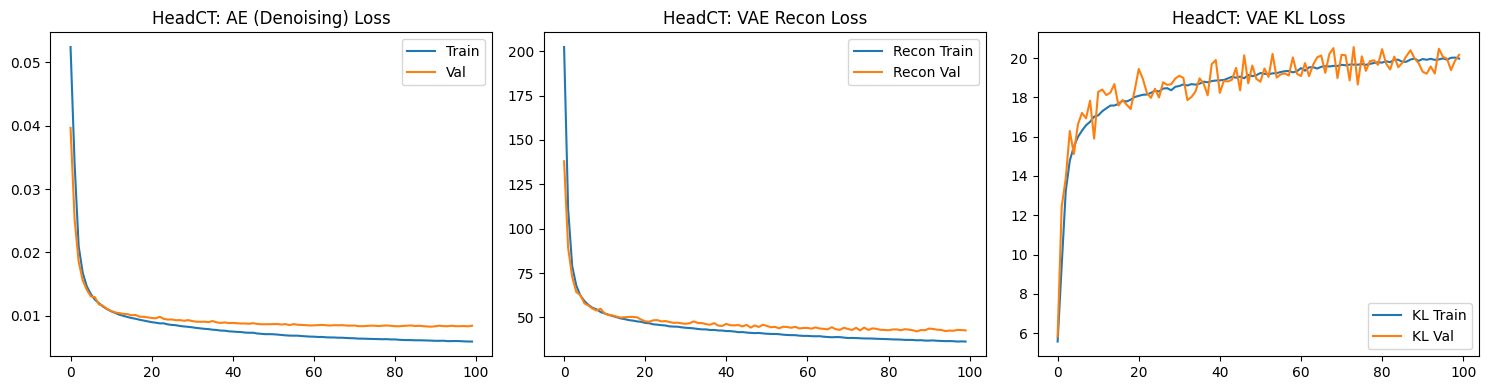

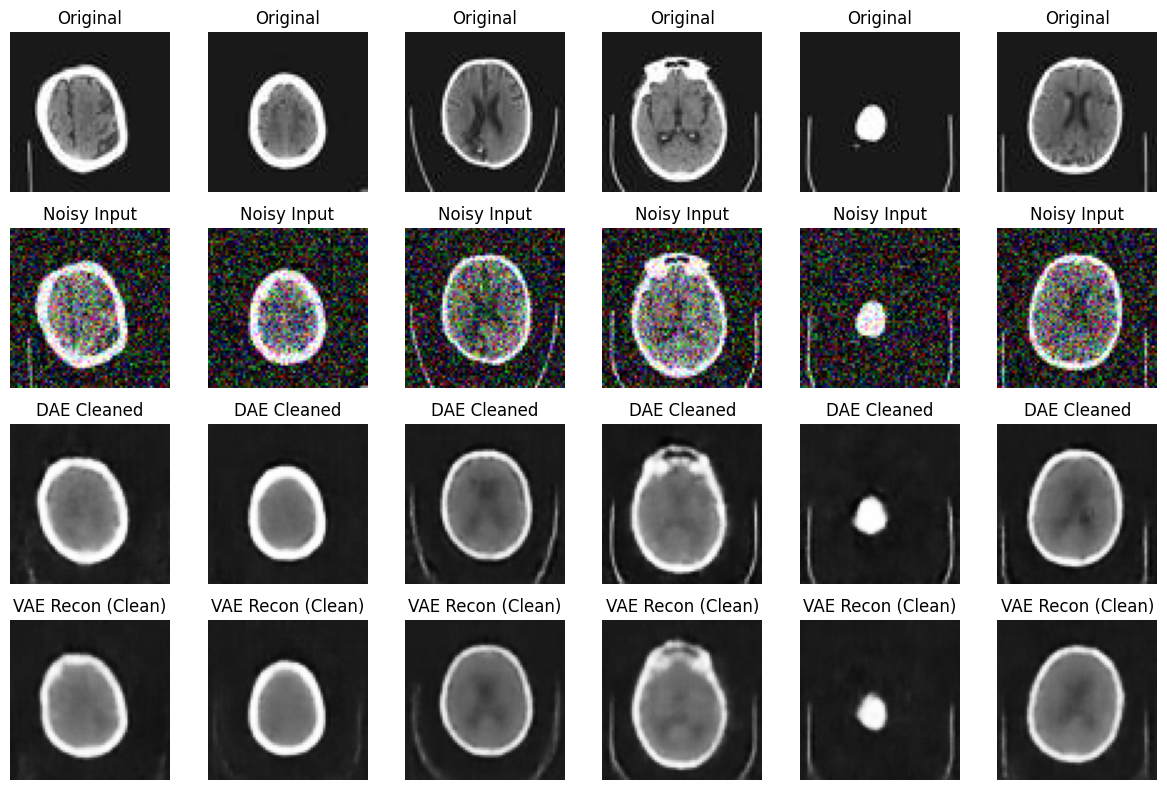

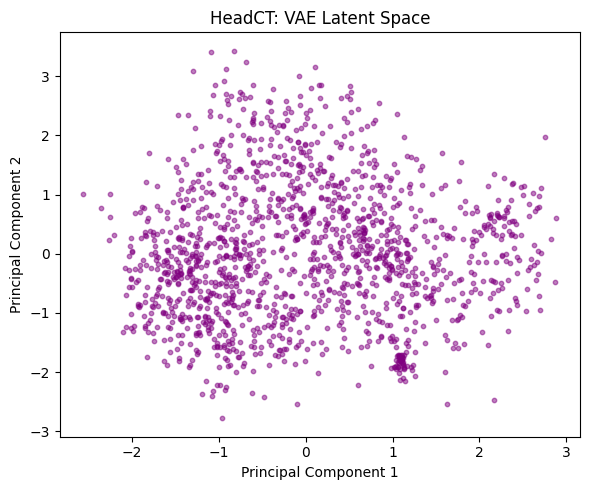

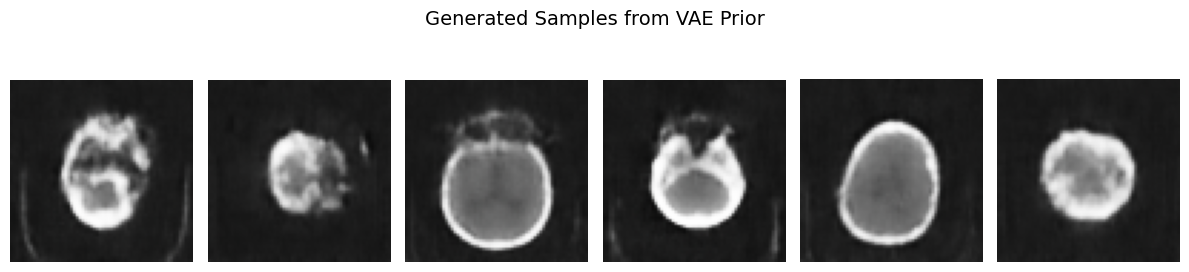

 FINISHED EXPERIMENT FOR REGION: HEADCT




In [12]:
tf.keras.backend.clear_session()
region = "HeadCT"
paths = region_data[region]

print(f" STARTING EXPERIMENT FOR REGION: {region.upper()}")

n_total = len(paths)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

train_paths = paths[:n_train]
val_paths = paths[n_train:n_train+n_val]
test_paths = paths[n_train+n_val:]

train_dae_ds = build_dataset(train_paths, mode='denoise', is_training=True)
val_dae_ds = build_dataset(val_paths, mode='denoise', is_training=False)
train_vae_ds = build_dataset(train_paths, mode='clean', is_training=True)
val_vae_ds = build_dataset(val_paths, mode='clean', is_training=False)
test_clean_ds = build_dataset(test_paths, mode='clean', is_training=False)
test_noisy_ds = build_dataset(test_paths, mode='denoise', is_training=False)

with strategy.scope():
    ae_model = ConvAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE)
    ae_model.compile(optimizer='adam', loss='mse')
    vae_model = ConvVAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE, beta=1.0)
    vae_model.compile(optimizer='adam')

print(f"\n--- Training Denoising AE for {region} ---")
ae_history = ae_model.fit(train_dae_ds, validation_data=val_dae_ds, epochs=EPOCHS, verbose=1)

print(f"\n--- Training VAE for {region} ---")
vae_history = vae_model.fit(train_vae_ds, validation_data=val_vae_ds, epochs=EPOCHS, verbose=1)

print(f"\n--- Generating Analytics for {region} ---")
plot_training_history(ae_history, vae_history, region)
evaluate_reconstruction_and_denoising(ae_model, vae_model, test_clean_ds, test_noisy_ds, n=6)
plot_latent_space(vae_model, test_clean_ds, title=f"{region}: VAE Latent Space")
generate_samples(vae_model, n=6)
print(f" FINISHED EXPERIMENT FOR REGION: {region.upper()}\n\n")